## Setup and config

This section imports core libraries and defines the key paths plus sampling knobs used in the EDA. The defaults keep runs fast while still touching multiple ROIs.

- Update `DATA_ROOT` if your dataset is in a different location.
- Increase `N_ROI_SAMPLE` and `N_PATCH_PER_ROI` for deeper coverage.

In [1]:
import sys
sys.executable


'c:\\Users\\bumba\\OneDrive\\Documents\\Spring 26\\Lock Docks\\SEN12MS\\.venv\\Scripts\\python.exe'

### Imports and configuration

Load core libraries, set dataset paths, sampling knobs, and random seeds for reproducible EDA.

In [2]:
from pathlib import Path
import random
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# GeoTIFF reading
import rasterio
from rasterio.errors import RasterioIOError

# -----------------------------
# CONFIG: update paths + sampling
# -----------------------------
DATA_ROOT = Path(r"C:\Users\bumba\OneDrive\Documents\Spring 26\Lock Docks\SEN12MS\ROIs1158_spring_s1\ROIs1158_spring")
ROI_GLOB = "s1_*"
ROI_DIR = DATA_ROOT / "s1_1"
DATASETS_ROOT = DATA_ROOT.parent.parent

# Sampling knobs for multi-ROI EDA
N_SAMPLE = 30
N_ROI_SAMPLE = 20
N_PATCH_PER_ROI = 5
PIXELS_PER_FILE = 5000
HIST_BINS = 200

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

if not ROI_DIR.exists():
    _roi_dirs = sorted([p for p in DATA_ROOT.glob(ROI_GLOB) if p.is_dir()])
    ROI_DIR = _roi_dirs[0] if _roi_dirs else DATA_ROOT

## Find patch files

We start with a single ROI (Region of Interest) folder to sanity-check file discovery and show a few patch names.

In [3]:
tifs = sorted(ROI_DIR.glob("*.tif"))
print(f"Found {len(tifs)} tif files in:\n  {ROI_DIR}")
print("First 5:")
for p in tifs[:5]:
    print(" ", p.name)

Found 784 tif files in:
  C:\Users\bumba\OneDrive\Documents\Spring 26\Lock Docks\SEN12MS\ROIs1158_spring_s1\ROIs1158_spring\s1_1
First 5:
  ROIs1158_spring_s1_1_p100.tif
  ROIs1158_spring_s1_1_p101.tif
  ROIs1158_spring_s1_1_p102.tif
  ROIs1158_spring_s1_1_p103.tif
  ROIs1158_spring_s1_1_p104.tif


## Inspect one file (metadata + array stats)

We read one GeoTIFF to verify metadata, band count, and value ranges before doing any large-scale aggregation.

Example: C:\Users\bumba\OneDrive\Documents\Spring 26\Lock Docks\SEN12MS\ROIs1158_spring_s1\ROIs1158_spring\s1_1\ROIs1158_spring_s1_1_p100.tif
=== METADATA ===
path: C:\Users\bumba\OneDrive\Documents\Spring 26\Lock Docks\SEN12MS\ROIs1158_spring_s1\ROIs1158_spring\s1_1\ROIs1158_spring_s1_1_p100.tif
driver: GTiff
width: 256
height: 256
count_bands: 2
dtypes: ('float32', 'float32')
crs: EPSG:32737
transform: | 10.00, 0.00, 390772.34|
| 0.00,-10.00, 8114182.84|
| 0.00, 0.00, 1.00|
nodata: None

=== PER-BAND STATS ===
{'band': 1, 'min': -20.313297271728516, 'max': -3.638587236404419, 'mean': -11.13450813293457, 'std': 2.0056371688842773, 'nan_frac': 0.0, 'zero_frac': 0.0}
{'band': 2, 'min': -28.220184326171875, 'max': -9.830634117126465, 'mean': -16.81448745727539, 'std': 2.1201417446136475, 'nan_frac': 0.0, 'zero_frac': 0.0}


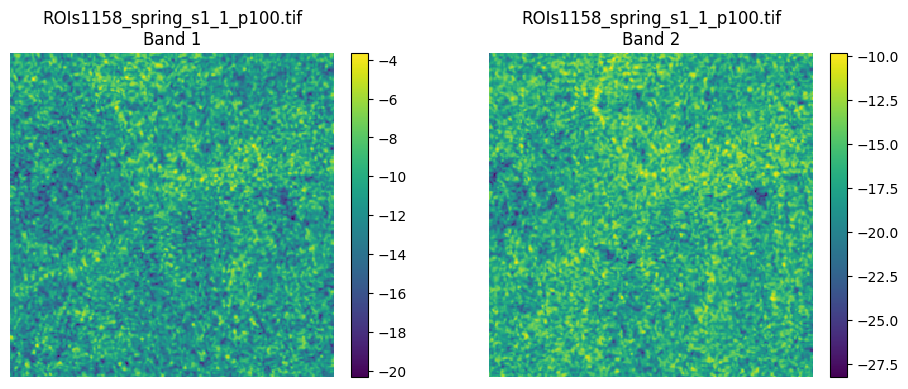

In [4]:
def inspect_tif(path: Path, show_plot: bool = True):
    try:
        with rasterio.open(path) as ds:
            meta = {
                "path": str(path),
                "driver": ds.driver,
                "width": ds.width,
                "height": ds.height,
                "count_bands": ds.count,
                "dtypes": ds.dtypes,           # tuple length = count
                "crs": str(ds.crs),
                "transform": ds.transform,
                "nodata": ds.nodata,
            }
            arr = ds.read()  # shape: (bands, H, W)
    except RasterioIOError as e:
        print(f"Failed to read {path}: {e}")
        return None

    # Basic stats per band
    stats = []
    for b in range(arr.shape[0]):
        x = arr[b]
        stats.append({
            "band": b + 1,
            "min": float(np.nanmin(x)),
            "max": float(np.nanmax(x)),
            "mean": float(np.nanmean(x)),
            "std": float(np.nanstd(x)),
            "nan_frac": float(np.isnan(x).mean()),
            "zero_frac": float((x == 0).mean()),
        })

    print("=== METADATA ===")
    for k, v in meta.items():
        print(f"{k}: {v}")

    print("\n=== PER-BAND STATS ===")
    for s in stats:
        print(s)

    if show_plot:
        # Quicklook each band
        bands = arr.shape[0]
        fig, axes = plt.subplots(1, bands, figsize=(5 * bands, 4))
        if bands == 1:
            axes = [axes]

        for i in range(bands):
            im = axes[i].imshow(arr[i], interpolation="nearest")
            axes[i].set_title(f"{path.name}\nBand {i+1}")
            axes[i].axis("off")
            plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

    return meta, stats, arr

# Pick a file to inspect
example = tifs[0] if tifs else None
print("Example:", example)
_ = inspect_tif(example, show_plot=True) if example else None


## Band scale heuristic (dB vs linear)

This quick check uses value ranges to guess whether the SAR bands look like dB-scale or linear-scale backscatter.

In [5]:
def sar_scale_heuristic(per_band_stats):
    """
    Rough heuristics:
    - dB SAR often lives around ~[-35, 5] (can vary)
    - linear backscatter is non-negative and often skewed (0..thousands)
    """
    verdicts = []
    for s in per_band_stats:
        mn, mx = s["min"], s["max"]
        if mn < 0 and mx < 50:
            verdicts.append("likely dB-scale-ish (has negatives)")
        elif mn >= 0 and mx > 100:
            verdicts.append("possibly linear-scale-ish (non-negative, large max)")
        else:
            verdicts.append("unclear")
    return verdicts

meta, stats, arr = inspect_tif(tifs[0], show_plot=False)
print("Heuristic:", sar_scale_heuristic(stats))


=== METADATA ===
path: C:\Users\bumba\OneDrive\Documents\Spring 26\Lock Docks\SEN12MS\ROIs1158_spring_s1\ROIs1158_spring\s1_1\ROIs1158_spring_s1_1_p100.tif
driver: GTiff
width: 256
height: 256
count_bands: 2
dtypes: ('float32', 'float32')
crs: EPSG:32737
transform: | 10.00, 0.00, 390772.34|
| 0.00,-10.00, 8114182.84|
| 0.00, 0.00, 1.00|
nodata: None

=== PER-BAND STATS ===
{'band': 1, 'min': -20.313297271728516, 'max': -3.638587236404419, 'mean': -11.13450813293457, 'std': 2.0056371688842773, 'nan_frac': 0.0, 'zero_frac': 0.0}
{'band': 2, 'min': -28.220184326171875, 'max': -9.830634117126465, 'mean': -16.81448745727539, 'std': 2.1201417446136475, 'nan_frac': 0.0, 'zero_frac': 0.0}
Heuristic: ['likely dB-scale-ish (has negatives)', 'likely dB-scale-ish (has negatives)']


## Consistency check across patches

We sample multiple patches and confirm that shape, band count, and dtype stay consistent.

In [6]:
def quick_consistency_check(paths, n=20):
    paths = list(paths)
    if not paths:
        print("No files.")
        return

    sample = random.sample(paths, k=min(n, len(paths)))

    shapes = set()
    dtypes = set()
    band_counts = set()

    for p in sample:
        with rasterio.open(p) as ds:
            shapes.add((ds.height, ds.width))
            dtypes.add(tuple(ds.dtypes))
            band_counts.add(ds.count)

    print(f"Sampled {len(sample)} files")
    print("Unique shapes:", shapes)
    print("Unique dtypes:", dtypes)
    print("Unique band counts:", band_counts)

quick_consistency_check(tifs, n=30)


Sampled 30 files
Unique shapes: {(256, 256)}
Unique dtypes: {('float32', 'float32')}
Unique band counts: {2}


## Dataset-wide stats (sampled)

We compute min/max/mean/std per band from a sampled subset to understand the overall range and spread.

In [7]:
def aggregate_stats(paths, n_sample=30):
    paths = list(paths)
    if not paths:
        return None

    sample = random.sample(paths, k=min(n_sample, len(paths)))

    band_sums = None
    band_sumsq = None
    band_mins = None
    band_maxs = None
    band_counts = None  # counts of finite pixels per band

    for p in sample:
        with rasterio.open(p) as ds:
            arr = ds.read().astype(np.float64)  # (B,H,W)
        B = arr.shape[0]

        if band_sums is None:
            band_sums = np.zeros(B, dtype=np.float64)
            band_sumsq = np.zeros(B, dtype=np.float64)
            band_mins = np.full(B, np.inf, dtype=np.float64)
            band_maxs = np.full(B, -np.inf, dtype=np.float64)
            band_counts = np.zeros(B, dtype=np.int64)

        for b in range(B):
            x = arr[b]
            finite = np.isfinite(x)
            xf = x[finite]
            if xf.size == 0:
                continue
            band_sums[b] += xf.sum()
            band_sumsq[b] += (xf * xf).sum()
            band_mins[b] = min(band_mins[b], xf.min())
            band_maxs[b] = max(band_maxs[b], xf.max())
            band_counts[b] += xf.size

    means = band_sums / np.maximum(band_counts, 1)
    vars_ = (band_sumsq / np.maximum(band_counts, 1)) - means**2
    stds = np.sqrt(np.maximum(vars_, 0))

    out = {
        "n_files_sampled": len(sample),
        "band_mins": band_mins,
        "band_maxs": band_maxs,
        "band_means": means,
        "band_stds": stds,
        "band_counts": band_counts,
    }
    return out

agg_local = aggregate_stats(tifs, n_sample=N_SAMPLE)
print("Sampled files (local ROI):", agg_local["n_files_sampled"] if agg_local else 0)
if agg_local:
    for b in range(len(agg_local["band_means"])):
        print({
            "band": b+1,
            "min": float(agg_local["band_mins"][b]),
            "max": float(agg_local["band_maxs"][b]),
            "mean": float(agg_local["band_means"][b]),
            "std": float(agg_local["band_stds"][b]),
            "n_pixels": int(agg_local["band_counts"][b]),
        })

Sampled files (local ROI): 30
{'band': 1, 'min': -27.808231353759766, 'max': 0.0, 'mean': -10.948494556551445, 'std': 2.883772100889104, 'n_pixels': 1966080}
{'band': 2, 'min': -38.31855773925781, 'max': 0.0, 'mean': -16.98242363578639, 'std': 3.130577442834734, 'n_pixels': 1966080}


## Histogram aggregation across many ROIs

We aggregate per-band histograms from patches sampled across many ROIs, then compare each ROI histogram to the global distribution to assess stability.

For SAR, include per-ROI histogram cosine-similarity bar and violin plots here to summarize how each ROI aligns with the global distribution.

In [8]:
def list_roi_dirs(base_dir: Path, pattern="s1_*"):
    base_dir = Path(base_dir)
    return sorted([p for p in base_dir.glob(pattern) if p.is_dir()])


def sample_paths_across_rois(roi_dirs, n_rois=20, n_per_roi=5, seed=42):
    rng = random.Random(seed)
    roi_dirs = list(roi_dirs)
    if not roi_dirs:
        return [], []

    roi_sample = rng.sample(roi_dirs, k=min(n_rois, len(roi_dirs)))
    paths = []

    for roi in roi_sample:
        tifs = sorted(roi.glob("*.tif"))
        if not tifs:
            continue
        paths.extend(rng.sample(tifs, k=min(n_per_roi, len(tifs))))

    return paths, roi_sample


def histogram_across_rois(roi_dirs, bins_per_band, n_per_roi=5, seed=42):
    rng = random.Random(seed)
    roi_dirs = list(roi_dirs)
    if not roi_dirs:
        return {}, [np.zeros(len(b) - 1, dtype=np.int64) for b in bins_per_band]

    global_hists = [np.zeros(len(b) - 1, dtype=np.int64) for b in bins_per_band]
    roi_hists = {}

    for roi in roi_dirs:
        tifs = sorted(roi.glob("*.tif"))
        if not tifs:
            continue
        sample = rng.sample(tifs, k=min(n_per_roi, len(tifs)))
        band_hists = [np.zeros(len(b) - 1, dtype=np.int64) for b in bins_per_band]

        for p in sample:
            with rasterio.open(p) as ds:
                arr = ds.read().astype(np.float64)
            for b in range(arr.shape[0]):
                x = arr[b]
                x = x[np.isfinite(x)]
                if x.size == 0:
                    continue
                hist, _ = np.histogram(x, bins=bins_per_band[b])
                band_hists[b] += hist
                global_hists[b] += hist

        roi_hists[roi.name] = {"n_files": len(sample), "hists": band_hists}

    return roi_hists, global_hists


def cosine_similarity(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom else float("nan")


roi_dirs = list_roi_dirs(DATA_ROOT, ROI_GLOB)
print(f"ROI dirs found: {len(roi_dirs)}")

roi_sample_paths, roi_sample_dirs = sample_paths_across_rois(
    roi_dirs, n_rois=N_ROI_SAMPLE, n_per_roi=N_PATCH_PER_ROI, seed=SEED
)
print(f"Sampled {len(roi_sample_dirs)} ROI dirs, {len(roi_sample_paths)} patches")

agg_global = aggregate_stats(roi_sample_paths, n_sample=len(roi_sample_paths))
if agg_global:
    bin_edges = [
        np.linspace(agg_global["band_mins"][b], agg_global["band_maxs"][b], HIST_BINS + 1)
        for b in range(len(agg_global["band_means"]))
    ]

    roi_hists, global_hists = histogram_across_rois(
        roi_sample_dirs, bin_edges, n_per_roi=N_PATCH_PER_ROI, seed=SEED
    )

    global_norm = [h / h.sum() if h.sum() else h for h in global_hists]

    print("Histogram stability (cosine similarity to global):")
    for b in range(len(global_hists)):
        sims = []
        for _roi_name, data in roi_hists.items():
            h = data["hists"][b]
            h_norm = h / h.sum() if h.sum() else h
            sims.append(cosine_similarity(h_norm, global_norm[b]))
        sims = [s for s in sims if np.isfinite(s)]
        if sims:
            print(f"Band {b+1}: min={min(sims):.3f} median={np.median(sims):.3f} max={max(sims):.3f}")
else:
    print("No ROI samples found for histogram aggregation.")

ROI dirs found: 56
Sampled 20 ROI dirs, 100 patches
Histogram stability (cosine similarity to global):
Band 1: min=0.456 median=0.935 max=0.975
Band 2: min=0.426 median=0.955 max=0.991


### Per-ROI histogram cosine similarity (SAR)

Plot per-ROI similarity to the global histogram with a bar chart and a violin plot.

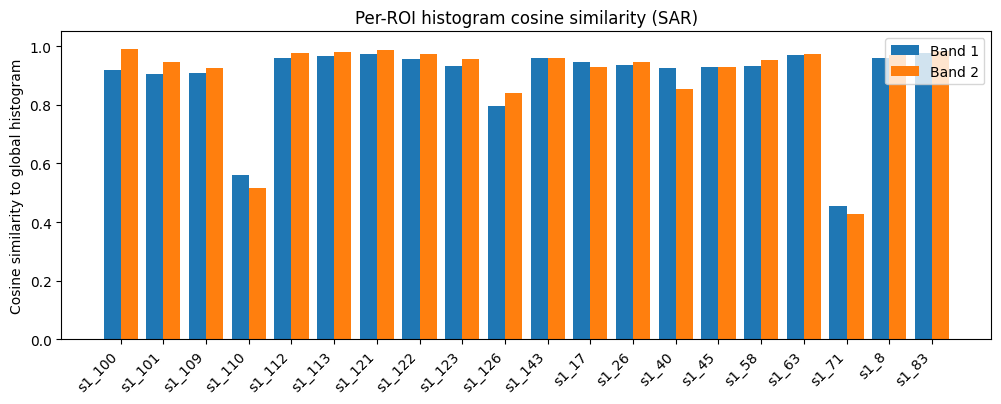

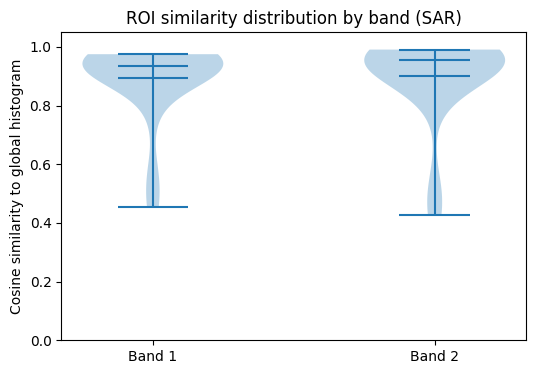

In [9]:
# Per-ROI cosine similarity plots (SAR histogram stability)
if agg_global and roi_hists:
    per_roi_sims = {}
    for roi_name, data in roi_hists.items():
        sims = []
        for b in range(len(global_hists)):
            h = data["hists"][b]
            h_norm = h / h.sum() if h.sum() else h
            sims.append(cosine_similarity(h_norm, global_norm[b]))
        per_roi_sims[roi_name] = np.array(sims, dtype=float)

    roi_names = [
        name for name, sims in per_roi_sims.items()
        if np.isfinite(sims).any()
    ]

    if roi_names:
        roi_names = sorted(roi_names)
        sims_by_band = np.array([per_roi_sims[name] for name in roi_names], dtype=float)
        n_bands = sims_by_band.shape[1]
        band_labels = [f"Band {b+1}" for b in range(n_bands)]

        # Bar plot: per-ROI cosine similarity
        fig, ax = plt.subplots(figsize=(12, 4))
        x = np.arange(len(roi_names))
        width = 0.8 / max(n_bands, 1)
        for b in range(n_bands):
            offset = (b - (n_bands - 1) / 2) * width
            ax.bar(x + offset, sims_by_band[:, b], width=width, label=band_labels[b])
        ax.set_xticks(x)
        ax.set_xticklabels(roi_names, rotation=45, ha="right")
        ax.set_ylabel("Cosine similarity to global histogram")
        ax.set_title("Per-ROI histogram cosine similarity (SAR)")
        ax.set_ylim(0, 1.05)
        ax.legend(loc="best")

        # Violin plot: distribution across ROIs
        fig, ax = plt.subplots(figsize=(6, 4))
        data = [
            [s for s in sims_by_band[:, b] if np.isfinite(s)]
            for b in range(n_bands)
        ]
        ax.violinplot(data, showmeans=True, showmedians=True)
        ax.set_xticks(np.arange(1, n_bands + 1))
        ax.set_xticklabels(band_labels)
        ax.set_ylabel("Cosine similarity to global histogram")
        ax.set_title("ROI similarity distribution by band (SAR)")
        ax.set_ylim(0, 1.05)
    else:
        print("No finite ROI histogram similarities to plot.")


## Inter-band correlation (VV vs VH)

We sample pixels from many ROIs and compute correlation between band 1 and band 2 to measure redundancy vs complementarity.

In [10]:
def sample_band_pairs(paths, band_a=1, band_b=2, pixels_per_file=5000, seed=42):
    rng = np.random.default_rng(seed)
    xs = []
    ys = []

    for p in paths:
        with rasterio.open(p) as ds:
            if ds.count < max(band_a, band_b):
                continue
            arr = ds.read([band_a, band_b]).astype(np.float64)
        a = arr[0]
        b = arr[1]
        mask = np.isfinite(a) & np.isfinite(b)
        idx = np.flatnonzero(mask)
        if idx.size == 0:
            continue
        take = min(pixels_per_file, idx.size)
        sample_idx = rng.choice(idx, size=take, replace=False)
        xs.append(a.ravel()[sample_idx])
        ys.append(b.ravel()[sample_idx])

    if not xs:
        return None, None
    return np.concatenate(xs), np.concatenate(ys)


def per_roi_correlation(roi_dirs, n_per_roi=5, seed=42):
    rng = random.Random(seed)
    rows = []

    for roi in roi_dirs:
        tifs = sorted(roi.glob("*.tif"))
        if not tifs:
            continue
        sample = rng.sample(tifs, k=min(n_per_roi, len(tifs)))
        x, y = sample_band_pairs(sample, pixels_per_file=PIXELS_PER_FILE, seed=seed)
        if x is None:
            continue
        corr = float(np.corrcoef(x, y)[0, 1])
        rows.append({"roi": roi.name, "corr": corr, "n": int(len(x))})

    return rows


x, y = sample_band_pairs(roi_sample_paths, pixels_per_file=PIXELS_PER_FILE, seed=SEED)
if x is not None:
    corr = float(np.corrcoef(x, y)[0, 1])
    print(f"Global sampled Pearson corr (band1 vs band2): {corr:.3f} (n={len(x)})")

    roi_corrs = per_roi_correlation(roi_sample_dirs, n_per_roi=N_PATCH_PER_ROI, seed=SEED)
    if roi_corrs:
        vals = [r["corr"] for r in roi_corrs if np.isfinite(r["corr"]) ]
        print(f"Per-ROI corr: min={min(vals):.3f} median={np.median(vals):.3f} max={max(vals):.3f}")
        worst = sorted(roi_corrs, key=lambda r: r["corr"])[:5]
        print("Lowest-corr ROIs:", [(r["roi"], round(r["corr"], 3), r["n"]) for r in worst])
else:
    print("Not enough data for correlation.")

Global sampled Pearson corr (band1 vs band2): 0.804 (n=500000)
Per-ROI corr: min=0.302 median=0.624 max=0.930
Lowest-corr ROIs: [('s1_45', 0.302, 25000), ('s1_58', 0.32, 25000), ('s1_17', 0.457, 25000), ('s1_122', 0.533, 25000), ('s1_109', 0.54, 25000)]


### VV vs VH scatter plots

Compare the global VV/VH relationship with selected ROIs (low/median/high correlation).

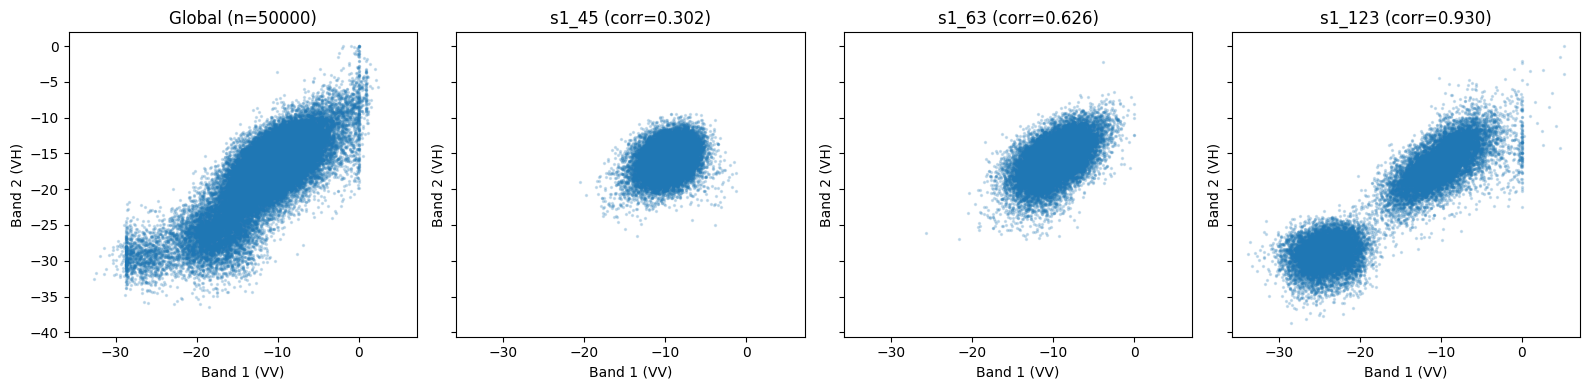

In [11]:
# VV vs VH scatter plots (global + selected ROIs)
if "x" in globals() and "y" in globals() and x is not None:
    def _subsample_xy(a, b, max_points=50000, seed=SEED):
        if a is None or b is None:
            return None, None
        n = len(a)
        if n <= max_points:
            return a, b
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=max_points, replace=False)
        return a[idx], b[idx]

    gx, gy = _subsample_xy(x, y, max_points=50000, seed=SEED)

    picks = []
    if "roi_corrs" in globals() and roi_corrs:
        roi_corrs_valid = [r for r in roi_corrs if np.isfinite(r.get("corr", np.nan))]
        if roi_corrs_valid:
            roi_corrs_sorted = sorted(roi_corrs_valid, key=lambda r: r["corr"])
            picks.append(roi_corrs_sorted[0])
            if len(roi_corrs_sorted) > 2:
                picks.append(roi_corrs_sorted[len(roi_corrs_sorted) // 2])
            if len(roi_corrs_sorted) > 1:
                picks.append(roi_corrs_sorted[-1])

    # Deduplicate picks by ROI name, preserve order
    seen = set()
    uniq_picks = []
    for r in picks:
        if r["roi"] not in seen:
            uniq_picks.append(r)
            seen.add(r["roi"])

    n_plots = 1 + len(uniq_picks)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharex=True, sharey=True)
    if n_plots == 1:
        axes = [axes]

    axes[0].scatter(gx, gy, s=2, alpha=0.2)
    axes[0].set_title(f"Global (n={len(gx)})")

    if uniq_picks and "roi_sample_dirs" in globals():
        roi_dir_map = {d.name: d for d in roi_sample_dirs}
        for ax, r in zip(axes[1:], uniq_picks):
            roi_dir = roi_dir_map.get(r["roi"])
            if roi_dir is None:
                ax.set_title(f"{r['roi']} (not sampled)")
                continue
            tifs = sorted(roi_dir.glob("*.tif"))
            if not tifs:
                ax.set_title(f"{r['roi']} (no files)")
                continue
            rng = random.Random(SEED)
            sample = rng.sample(tifs, k=min(N_PATCH_PER_ROI, len(tifs)))
            rx, ry = sample_band_pairs(sample, pixels_per_file=PIXELS_PER_FILE, seed=SEED)
            if rx is None:
                ax.set_title(f"{r['roi']} (no data)")
                continue
            rx, ry = _subsample_xy(rx, ry, max_points=20000, seed=SEED)
            ax.scatter(rx, ry, s=2, alpha=0.2)
            ax.set_title(f"{r['roi']} (corr={r['corr']:.3f})")
    elif len(axes) > 1:
        for ax in axes[1:]:
            ax.set_title("ROI samples not available")

    for ax in axes:
        ax.set_xlabel("Band 1 (VV)")
        ax.set_ylabel("Band 2 (VH)")

    plt.tight_layout()
else:
    print("Run the inter-band correlation cell first to compute x/y samples.")


## ROI-level statistics

We compute mean and std per ROI (per band) to detect geographic bias or outlier regions.

In [12]:
def roi_level_stats(roi_dirs, n_per_roi=5, seed=42):
    rng = random.Random(seed)
    rows = []

    for roi in roi_dirs:
        tifs = sorted(roi.glob("*.tif"))
        if not tifs:
            continue
        sample = rng.sample(tifs, k=min(n_per_roi, len(tifs)))
        stats = aggregate_stats(sample, n_sample=len(sample))
        if not stats:
            continue
        rows.append({
            "roi": roi.name,
            "n_files": len(sample),
            "means": stats["band_means"],
            "stds": stats["band_stds"],
        })

    return rows


roi_stats = roi_level_stats(roi_sample_dirs, n_per_roi=N_PATCH_PER_ROI, seed=SEED)
if roi_stats and agg_global:
    global_means = agg_global["band_means"]
    print("ROI mean deviations from global mean:")
    for b in range(len(global_means)):
        diffs = sorted(
            roi_stats,
            key=lambda r: abs(float(r["means"][b]) - float(global_means[b])),
            reverse=True,
        )[:5]
        print(f"Band {b+1} top deviations:", [
            (r["roi"], round(float(r["means"][b]), 3), round(float(r["means"][b] - global_means[b]), 3))
            for r in diffs
        ])
else:
    print("ROI-level stats skipped (no samples or no global stats).")

ROI mean deviations from global mean:
Band 1 top deviations: [('s1_110', -16.437, -5.259), ('s1_71', -15.92, -4.742), ('s1_40', -7.981, 3.197), ('s1_100', -8.148, 3.03), ('s1_123', -13.62, -2.442)]
Band 2 top deviations: [('s1_71', -23.322, -5.723), ('s1_110', -23.305, -5.706), ('s1_40', -13.401, 4.198), ('s1_17', -15.049, 2.55), ('s1_45', -15.395, 2.204)]


### SAR per-ROI mean deviation plot

Visualize how each ROI?s band means deviate from the global mean (absolute deviation).

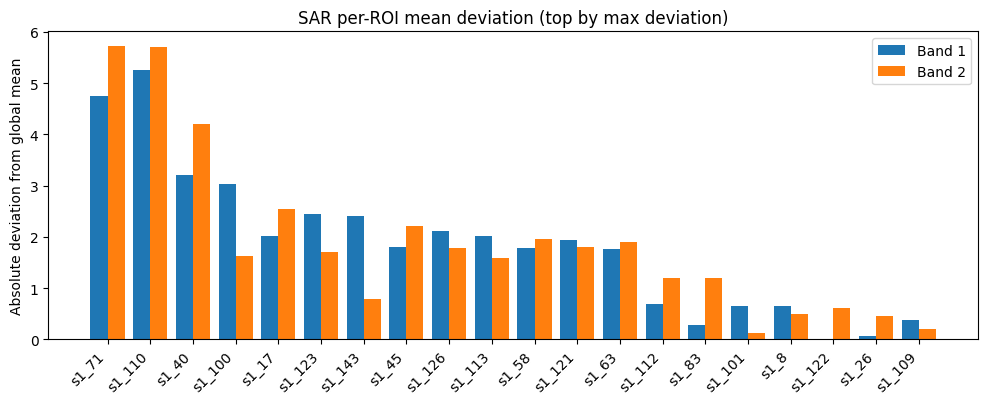

In [13]:
# SAR per-ROI mean deviation plot
if roi_stats and agg_global:
    global_means = np.array(agg_global["band_means"], dtype=float)
    roi_names = [r["roi"] for r in roi_stats]
    means = np.array([r["means"] for r in roi_stats], dtype=float)
    if means.ndim == 1:
        means = means[:, None]
    abs_dev = np.abs(means - global_means[None, :])

    order = np.argsort(abs_dev.max(axis=1))[::-1]
    roi_names = [roi_names[i] for i in order]
    abs_dev = abs_dev[order]

    max_show = 20
    if len(roi_names) > max_show:
        roi_names = roi_names[:max_show]
        abs_dev = abs_dev[:max_show]

    n_bands = abs_dev.shape[1]
    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(len(roi_names))
    width = 0.8 / max(n_bands, 1)
    for b in range(n_bands):
        offset = (b - (n_bands - 1) / 2) * width
        ax.bar(x + offset, abs_dev[:, b], width=width, label=f"Band {b+1}")
    ax.set_xticks(x)
    ax.set_xticklabels(roi_names, rotation=45, ha="right")
    ax.set_ylabel("Absolute deviation from global mean")
    ax.set_title("SAR per-ROI mean deviation (top by max deviation)")
    ax.legend(loc="best")
else:
    print("ROI-level stats not available for mean deviation plot.")


## Optional: single-band histogram

A quick histogram from one patch helps validate the scale and distribution shape.

In [ ]:
def plot_histogram_one_band(path: Path, band=1, bins=200):
    with rasterio.open(path) as ds:
        x = ds.read(band).astype(np.float64)
    x = x[np.isfinite(x)]
    plt.figure(figsize=(6,4))
    plt.hist(x.ravel(), bins=bins)
    plt.title(f"Histogram: {path.name} (band {band})")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_histogram_one_band(tifs[0], band=1)
